<a href="https://colab.research.google.com/github/mohnish-2460git/Drug-Python-Classification/blob/main/clasification_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Objectives

After completing this lab you will be able to:

*   Develop a various classification algorithms

In this lab exercise, you will learn a various classification machine learning algorithms. You will use the classification algorithms to build a model from the historical data of patients, and their response to different medications. Then you will use the trained decision tree to predict the class of an unknown patient, or to find a proper drug for a new patient.


[GitHub Link](https://github.com/ci250072-hue/classificationDrugPyProg.git)

<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="https://#about_dataset">About the dataset</a></li>
        <li><a href="https://#downloading_data">Downloading the Data</a></li>
        <li><a href="https://#pre-processing">Pre-processing</a></li>
        <li><a href="https://#setting_up_tree">Setting up the Decision Tree</a></li>
        <li><a href="https://#modeling">Modeling</a></li>
        <li><a href="https://#prediction">Prediction</a></li>
        <li><a href="https://#evaluation">Evaluation</a></li>
        <li><a href="https://#visualization">Visualization</a></li>
    </ol>
</div>
<br>
<hr>


Import the Following Libraries:

<ul>
    <li> <b>numpy as np</b> </li>
    <li> <b>pandas as pd</b> </li>
    <li> <b>matplotlib.pyplot as plt</b> </li>
    <li> <b>seaborn as sns</b> </li>
    <li> <b>train_test_split</b> from <b>sklearn.model_selection</b> </li>
    <li> <b>LabelEncoder or OneHotEncoder</b> (which ever you prefer) from <b>sklearn.preprocessing</b> </li>
    <li> <b>GausianNB</b> from <b>sklearn.naive_bayes</b> </li>
    <li> <b>metrics</b> from <b>sklearn.metrics</b> </li>

</ul>


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

<div id="about_dataset">
    <h2>About the dataset</h2>
    Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A, Drug B, Drug c, Drug x and y.
    <br>
    <br>
    Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are Age, Sex, Blood Pressure, and the Cholesterol of the patients, and the target is the drug that each patient responded to.
    <br>
    <br>
    It is a sample of multiclass classifier, and you can use the training part of the dataset
    to build a decision tree, and then use it to predict the class of an unknown patient, or to prescribe a drug to a new patient.
    <br>
    Typical features in the dataset:
     <li>Age (numeric)
     <li>Sex (categorical: M, F)
     <li>BP (categorical: HIGH, NORMAL, LOW)
     <li>Cholesterol (categorical: HIGH, NORMAL)
     <li>Na_to_K (numeric: Sodium/Potassium ratio)
     <li>Drug (target label)
</div>


<div id="downloading_data">
    <h2>Load the Data</h2>
</div>

Now, load the data using pandas dataframe:


In [ ]:
drug = pd.read_csv("drug200.csv")

In [ ]:
drug

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


<div id="Explore the data">
    <h3>Explore the data</h3>
    What is the size of data?
    What is the data descriptive?
</div>


In [ ]:
# write your code here
print(drug.shape)
print(drug.describe(include='all'))

(200, 6)
               Age  Sex    BP Cholesterol     Na_to_K   Drug
count   200.000000  200   200         200  200.000000    200
unique         NaN    2     3           2         NaN      5
top            NaN    M  HIGH        HIGH         NaN  drugY
freq           NaN  104    77         103         NaN     91
mean     44.315000  NaN   NaN         NaN   16.084485    NaN
std      16.544315  NaN   NaN         NaN    7.223956    NaN
min      15.000000  NaN   NaN         NaN    6.269000    NaN
25%      31.000000  NaN   NaN         NaN   10.445500    NaN
50%      45.000000  NaN   NaN         NaN   13.936500    NaN
75%      58.000000  NaN   NaN         NaN   19.380000    NaN
max      74.000000  NaN   NaN         NaN   38.247000    NaN


<div href="pre-processing">
    <h2>Pre-processing</h2>
</div>


Using <b>my_data</b> as the Drug.csv data read by pandas, declare the following variables: <br>

<ul>
    <li> <b> X </b> as the <b> Feature Matrix </b> (data of my_data) </li>
    <li> <b> X </b> is 'Age', 'Sex_n', 'BP_n', 'Chol_n', 'Na_to_K'</li>
    <li> <b> Y </b> as the <b> response vector </b> (target) </li>
    <li> Y is 'Drug'</li>
</ul>


Remove the column containing the target name since it doesn't contain numeric values.


In [ ]:
#split data into X and Y
X=drug.iloc[:,:-1].values
Y=drug.iloc[:,-1].values
print(X)
print(Y)

[[23 'F' 'HIGH' 'HIGH' 25.355]
 [47 'M' 'LOW' 'HIGH' 13.093]
 [47 'M' 'LOW' 'HIGH' 10.114]
 [28 'F' 'NORMAL' 'HIGH' 7.798]
 [61 'F' 'LOW' 'HIGH' 18.043]
 [22 'F' 'NORMAL' 'HIGH' 8.607]
 [49 'F' 'NORMAL' 'HIGH' 16.275]
 [41 'M' 'LOW' 'HIGH' 11.037]
 [60 'M' 'NORMAL' 'HIGH' 15.171]
 [43 'M' 'LOW' 'NORMAL' 19.368]
 [47 'F' 'LOW' 'HIGH' 11.767]
 [34 'F' 'HIGH' 'NORMAL' 19.199]
 [43 'M' 'LOW' 'HIGH' 15.376]
 [74 'F' 'LOW' 'HIGH' 20.942]
 [50 'F' 'NORMAL' 'HIGH' 12.703]
 [16 'F' 'HIGH' 'NORMAL' 15.516]
 [69 'M' 'LOW' 'NORMAL' 11.455]
 [43 'M' 'HIGH' 'HIGH' 13.972]
 [23 'M' 'LOW' 'HIGH' 7.298]
 [32 'F' 'HIGH' 'NORMAL' 25.974]
 [57 'M' 'LOW' 'NORMAL' 19.128]
 [63 'M' 'NORMAL' 'HIGH' 25.917]
 [47 'M' 'LOW' 'NORMAL' 30.568]
 [48 'F' 'LOW' 'HIGH' 15.036]
 [33 'F' 'LOW' 'HIGH' 33.486]
 [28 'F' 'HIGH' 'NORMAL' 18.809]
 [31 'M' 'HIGH' 'HIGH' 30.366]
 [49 'F' 'NORMAL' 'NORMAL' 9.381]
 [39 'F' 'LOW' 'NORMAL' 22.697]
 [45 'M' 'LOW' 'HIGH' 17.951]
 [18 'F' 'NORMAL' 'NORMAL' 8.75]
 [74 'M' 'HIGH' 'HIGH' 

As you may figure out, some features in this dataset are categorical, such as **Sex** or **BP**. Convert the categorical variable into dummy/indicator variables.


In [ ]:
#label encoder or OneHotEncoder for Sex, BP and Cholesterol
bp_mapping={'LOW':0,'NORMAL':1,'HIGH':2}
chol_mapping={'NORMAL':0,'HIGH':1}
drug['BP_n']=drug['BP'].map(bp_mapping)
drug['Chol_n']=drug['Cholesterol'].map(chol_mapping)
drug['Sex_n']=drug['Sex'].map({'F':0,'M':1})
X=drug[['Age','Sex_n','BP_n','Chol_n','Na_to_K']].values
Y=drug['Drug'].values
print("Encoded Feature Matrix X (First 5 rows):")
print(X[0:5])

Encoded Feature Matrix X (First 5 rows):
[[23.     0.     2.     1.    25.355]
 [47.     1.     0.     1.    13.093]
 [47.     1.     0.     1.    10.114]
 [28.     0.     1.     1.     7.798]
 [61.     0.     0.     1.    18.043]]


Print the target variable.


In [ ]:
#print y
print(drug['Drug'])

0      drugY
1      drugC
2      drugC
3      drugX
4      drugY
       ...  
195    drugC
196    drugC
197    drugX
198    drugX
199    drugX
Name: Drug, Length: 200, dtype: object


<hr>

<div id="Model Setting">
    <h2>Setting up the Naive Bayes Algorithm</h2>
    We will be using <b>train/test split</b> on our algorithms </b>. Let's import <b>train_test_split</b> from <b>sklearn.model_selection</b>.
</div>


Now <b> train_test_split </b> will return 4 different parameters. We will name them:<br>
X_trainset, X_testset, Y_trainset, Y_testset <br> <br>
The <b> train_test_split </b> will need the parameters: <br>
X, y, test_size=0.3, and random_state=3. <br> <br>
The <b>X</b> and <b>y</b> are the arrays required before the split, the <b>test_size</b> represents the ratio of the testing dataset, and the <b>random_state</b> ensures that the dataset were split at random with consistent shuffle.


In [ ]:
#write your code here
X_trainset,X_testset,Y_trainset,Y_testset=train_test_split(X,Y,test_size=0.3,random_state=3)


Print the shape of X_trainset and y_trainset. Ensure that the dimensions match the prior splitting request.


In [ ]:
print(f"Training features size: {X_trainset.shape}")
print(f"Testing features size: {X_testset.shape}")

Training features size: (140, 5)
Testing features size: (60, 5)



Print the shape of X_testset and y_testset.


In [ ]:
# your code
print(f"Testing features size of X: {X_testset.shape}")
print(f"Testing features size of Y: {Y_testset.shape}")


Testing features size of X: (60, 5)
Testing features size of Y: (60,)


<hr>

<div id="modeling">
    <h2>Modeling</h2>
    Lets create an instance of the <b>Naive Bayes</b>.

</div>


In [ ]:
# Create a Naive Bayes classifier and name it as Model_NB1

Model_NB1 = GaussianNB()

Next, we will fit the data with the training feature matrix <b> X_trainset </b> and training  response vector <b> y_trainset </b>


In [ ]:
# Train the classifier with X_trainset and Y_trainset

Model_NB1.fit(X_trainset, Y_trainset)

GaussianNB()

<hr>

<div id="prediction">
    <h2>Prediction</h2>
    Let's make some <b>predictions</b> on the testing dataset and store it into a variable called <b>predNB1</b>.
</div>


In [ ]:
#make prediction for Model_NB1 (Naive Bayes)

predNB1 = Model_NB1.predict(X_testset)

You can print out <b>predNB1</b> and <b>y_testset</b> if you want to visually compare the predictions to the actual values.





In [ ]:
#Compare the predicted Y for Model_NB1 vs Actual Y Test

print(predNB1)
print(Y_testset)

['drugY' 'drugX' 'drugX' 'drugX' 'drugX' 'drugC' 'drugA' 'drugA' 'drugB'
 'drugA' 'drugY' 'drugA' 'drugY' 'drugY' 'drugX' 'drugY' 'drugX' 'drugX'
 'drugB' 'drugX' 'drugX' 'drugB' 'drugC' 'drugY' 'drugX' 'drugB' 'drugY'
 'drugY' 'drugA' 'drugX' 'drugB' 'drugC' 'drugC' 'drugY' 'drugX' 'drugC'
 'drugC' 'drugX' 'drugX' 'drugX' 'drugA' 'drugA' 'drugC' 'drugA' 'drugA'
 'drugY' 'drugY' 'drugY' 'drugC' 'drugX' 'drugB' 'drugX' 'drugY' 'drugX'
 'drugY' 'drugB' 'drugA' 'drugX' 'drugY' 'drugX']
['drugY' 'drugX' 'drugX' 'drugX' 'drugX' 'drugC' 'drugY' 'drugA' 'drugB'
 'drugA' 'drugY' 'drugA' 'drugY' 'drugY' 'drugX' 'drugY' 'drugX' 'drugX'
 'drugB' 'drugX' 'drugX' 'drugY' 'drugY' 'drugY' 'drugX' 'drugB' 'drugY'
 'drugY' 'drugA' 'drugX' 'drugB' 'drugC' 'drugC' 'drugX' 'drugX' 'drugC'
 'drugY' 'drugX' 'drugX' 'drugX' 'drugA' 'drugY' 'drugC' 'drugY' 'drugA'
 'drugY' 'drugY' 'drugY' 'drugY' 'drugX' 'drugB' 'drugX' 'drugY' 'drugX'
 'drugY' 'drugY' 'drugA' 'drugX' 'drugY' 'drugX']


<hr>

<div id="evaluation">
    <h2>Evaluation</h2>
    Next, let's check the accuracy of our model.
</div>


In [ ]:
#check the confusion matrix

conf = confusion_matrix(Y_testset, predNB1, )
print(conf)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 3  2  3  0 14]]


In [ ]:
#check the accuracy

acc = accuracy_score(Y_testset, predNB1)
print(acc)

0.85


In [ ]:
#check the classification report

report = classification_report(Y_testset, predNB1)
print(report)

              precision    recall  f1-score   support

       drugA       0.70      1.00      0.82         7
       drugB       0.71      1.00      0.83         5
       drugC       0.62      1.00      0.77         5
       drugX       1.00      0.95      0.98        21
       drugY       0.93      0.64      0.76        22

    accuracy                           0.85        60
   macro avg       0.79      0.92      0.83        60
weighted avg       0.89      0.85      0.85        60



**Accuracy classification score** computes subset accuracy: the set of labels predicted for a sample must exactly match the corresponding set of labels in y_true.

In multilabel classification, the function returns the subset accuracy. If the entire set of predicted labels for a sample strictly matches with the true set of labels, then the subset accuracy is 1.0; otherwise it is 0.0.


<hr>

<div id="visualization">
    <h2>Visualization</h2>

Let's visualize Confusion Matrix using heatmap.

</div>


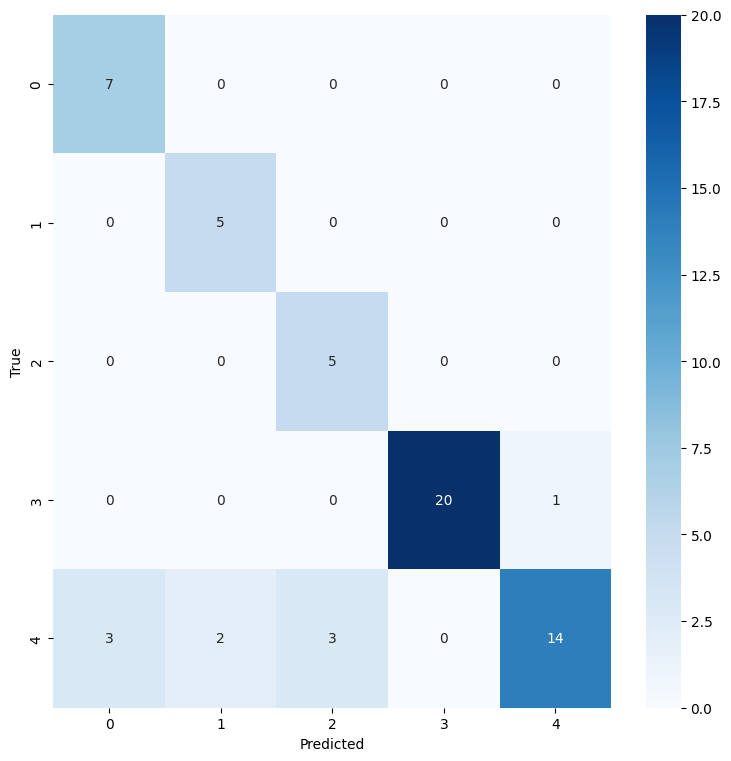

In [ ]:
#heatmap for confusion matrix

plt.figure(figsize=(9,9))
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



# Another variant of Naive Bayes

In [ ]:
# try to set the parameter such as var_smoothing or alpha in the models
# let try using another variant of naive bayes such as Multinomial and Bernoulli
# split the data using cross validation technique
# compare the performance of each models


In [ ]:
#make prediction for Model_NB2 (Multinomial Naive Bayes)
# Initialize Model_NB2
Model_NB2 = MultinomialNB(alpha=1.0)

# Train the model
Model_NB2.fit(X_trainset, Y_trainset)

# Make predictions
Y_pred_nb2 = Model_NB2.predict(X_testset)
print(confusion_matrix(Y_testset, Y_pred_nb2))

# Print the blank space and accuracy score
print()
print(accuracy_score(Y_testset, Y_pred_nb2))


[[ 4  0  0  0  3]
 [ 0  1  0  4  0]
 [ 0  0  0  4  1]
 [ 0  0  0 15  6]
 [ 2  0  1  9 10]]

0.5


In [ ]:
#make prediction for Model_NB3 (Categorical Naive Bayes)
# Initialize Model_NB3
Model_NB3 = CategoricalNB()

# Train the model
Model_NB3.fit(X_trainset, Y_trainset)

# Make predictions
Y_pred_nb3 = Model_NB3.predict(X_testset)
print(confusion_matrix(Y_testset, Y_pred_nb3))

# Print the blank space and accuracy score
print()
print(accuracy_score(Y_testset, Y_pred_nb3))


[[ 1  4  0  0  2]
 [ 1  2  0  0  2]
 [ 0  0  3  2  0]
 [ 0  0  0 21  0]
 [ 0  0  0  0 22]]

0.8166666666666667


In [ ]:
#make prediction for Model_NB5 (Gaussian Naive Bayes) with alpha
Model_NB5=GaussianNB(var_smoothing=1e-9)
Model_NB5.fit(X_trainset,Y_trainset)
Y_pred_nb5=Model_NB5.predict(X_testset)

print(confusion_matrix(Y_testset,Y_pred_nb5))
print()
print(accuracy_score(Y_testset, Y_pred_nb5))

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 3  2  3  0 14]]

0.85


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
Model_LR=LogisticRegression(max_iter=5000,random_state=3)
Model_LR.fit(X_trainset,Y_trainset)
Y_pred_lr=Model_LR.predict(X_testset)
print(confusion_matrix(Y_testset, Y_pred_lr))
print()
print(accuracy_score(Y_testset, Y_pred_lr))

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  1  0 19  1]
 [ 0  1  1  0 20]]

0.9333333333333333


Another variant of Logistic Regression

In [ ]:
# solver='liblinear' is required because the default solver (lbfgs) doesn't support L1
Model_LR_L1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=3)

# Train the model
Model_LR_L1.fit(X_trainset, Y_trainset)
Y_pred_lr_l1 = Model_LR_L1.predict(X_testset)
# Print the raw matrix array
print(confusion_matrix(Y_testset, Y_pred_lr_l1))

# Print the blank space and accuracy score
print()
print(accuracy_score(Y_testset, Y_pred_lr_l1))

[[ 6  0  0  0  1]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 19  2]
 [ 0  1  0  0 21]]

0.9333333333333333


# Decison Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
# max_depth=4 limits the tree's size to prevent it from overfitting
Model_Tree = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=3)

# Train the model
Model_Tree.fit(X_trainset, Y_trainset)

# Make predictions
Y_pred_tree = Model_Tree.predict(X_testset)
print(confusion_matrix(Y_testset, Y_pred_tree))

# Print the blank space and accuracy score
print()
print(accuracy_score(Y_testset, Y_pred_tree))

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

0.9833333333333333


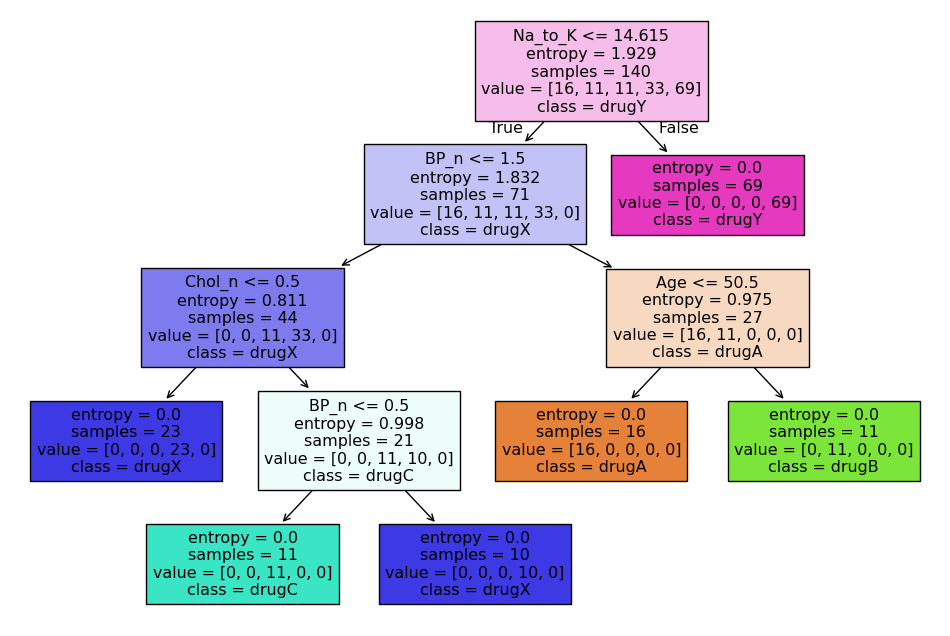

In [ ]:
from sklearn import tree

# Set up the figure size
plt.figure(figsize=(12, 8))

# Plot the tree layout structure
tree.plot_tree(Model_Tree,
               feature_names=['Age', 'Sex_n', 'BP_n', 'Chol_n', 'Na_to_K'],
               class_names=sorted(list(set(Y))),
               filled=True)

plt.show()

Another variant of Decision Tree

In [ ]:
Model_Tree_Gini = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=3)

# Train the model
Model_Tree_Gini.fit(X_trainset, Y_trainset)

# Make predictions
Y_pred_tree_gini = Model_Tree_Gini.predict(X_testset)
print(confusion_matrix(Y_testset, Y_pred_tree_gini))

# Print the blank space and accuracy score
print()
print(accuracy_score(Y_testset, Y_pred_tree_gini))

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

0.9833333333333333


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Model_RF=RandomForestClassifier(n_estimators=100,criterion="entropy",random_state=3)
Model_RF.fit(X_trainset,Y_trainset)
Y_pred_rf=Model_RF.predict(X_testset)
# Print the raw matrix array
print(confusion_matrix(Y_testset, Y_pred_rf))

# Print the blank space and accuracy score
print()
print(accuracy_score(Y_testset, Y_pred_rf))

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

0.9833333333333333


# KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN (Checking the 5 closest neighbors)
Model_KNN = KNeighborsClassifier(n_neighbors=5)
Model_KNN.fit(X_trainset, Y_trainset)

# Predict and Output (Lab Format)
Y_pred_knn = Model_KNN.predict(X_testset)
print(confusion_matrix(Y_testset, Y_pred_knn))
print()
print(accuracy_score(Y_testset, Y_pred_knn))

[[ 4  0  2  1  0]
 [ 0  5  0  0  0]
 [ 1  2  1  1  0]
 [ 3  9  1  8  0]
 [ 0  0  2  0 20]]

0.6333333333333333


# Support Vector Machine (Classification)

In [ ]:
from sklearn.svm import SVC

# Initialize Linear SVM
Model_SVM_Linear = SVC(kernel='linear', random_state=3)
Model_SVM_Linear.fit(X_trainset, Y_trainset)

# Predict and Output (Lab Format)
Y_pred_svm_lin = Model_SVM_Linear.predict(X_testset)
print(confusion_matrix(Y_testset, Y_pred_svm_lin))
print()
print(accuracy_score(Y_testset, Y_pred_svm_lin))

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 21  0]
 [ 1  1  1  0 19]]

0.95


Another variant of SVC

In [ ]:
# Initialize Non-Linear SVM using the RBF kernel
Model_SVM_RBF = SVC(kernel='rbf', random_state=3)
Model_SVM_RBF.fit(X_trainset, Y_trainset)

# Predict and Output (Lab Format)
Y_pred_svm_rbf = Model_SVM_RBF.predict(X_testset)
print(confusion_matrix(Y_testset, Y_pred_svm_rbf))
print()
print(accuracy_score(Y_testset, Y_pred_svm_rbf))

[[ 0  0  0  7  0]
 [ 0  0  0  3  2]
 [ 0  0  0  5  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

0.7


Explain your findings

Decision Tree classifiers  is the most suitable model for this dataset, achieving the highest overall test accuracy of 98.33% which are 59 out of 60 patients correctly classified.Although the Random Forest model matched this score perfectly but introduces unecessary computational complexity for a dataset that a single, clean can already solve.

Basically, medical prescription guidelines are naturally built on strict, sequential, "if-then" conditional thresholds. Thus, decision trees can split easily and funneling into the correct bucket without diluting the power of a rule with other features.

Naive Bayes failed because it assumes that all features are completely independent. In human biology, features such as age, blood pressure and sodium levels are highly correlated. Furthermore, forcing smooth bell curves (Gaussian) onto sharp threshold switches or treating continuous scales as word counts (Multinomial) breaks the foundational probability math of the algorithms.

KNN and RBF SVM are heavily rely on geometric distance metrics.It's because the dataset features were left unscaled, features with larger raw numerical ranges completely overwhelmed and blinded the distance calculations to features with tiny ranges.